In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report, 
                              confusion_matrix, roc_curve)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Load our cleaned dataset - notice how fast this is vs the raw CSV
data_path = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\outputs\loans_cleaned.parquet"

df = pd.read_parquet(data_path)

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")
print(f"Default rate: {df['target'].mean()*100:.2f}%")

Loaded 1,344,441 rows and 79 columns
Default rate: 19.96%


In [5]:
# Separate our features (X) from what we're trying to predict (y)
X = df.drop(columns=['target'])
y = df['target']

print(f"Features (X): {X.shape}")
print(f"Target (y):   {y.shape}")
print(f"\nFeature list:")
for i, col in enumerate(X.columns):
    print(f"  {i+1:>3}. {col}")

Features (X): (1344441, 78)
Target (y):   (1344441,)

Feature list:
    1. loan_amnt
    2. term
    3. int_rate
    4. installment
    5. grade
    6. emp_length
    7. annual_inc
    8. dti
    9. delinq_2yrs
   10. inq_last_6mths
   11. open_acc
   12. pub_rec
   13. revol_bal
   14. revol_util
   15. total_acc
   16. collections_12_mths_ex_med
   17. acc_now_delinq
   18. tot_coll_amt
   19. tot_cur_bal
   20. total_rev_hi_lim
   21. acc_open_past_24mths
   22. avg_cur_bal
   23. bc_open_to_buy
   24. bc_util
   25. chargeoff_within_12_mths
   26. delinq_amnt
   27. mo_sin_old_il_acct
   28. mo_sin_old_rev_tl_op
   29. mo_sin_rcnt_rev_tl_op
   30. mo_sin_rcnt_tl
   31. mort_acc
   32. mths_since_recent_bc
   33. mths_since_recent_inq
   34. num_accts_ever_120_pd
   35. num_actv_bc_tl
   36. num_actv_rev_tl
   37. num_bc_sats
   38. num_bc_tl
   39. num_il_tl
   40. num_op_rev_tl
   41. num_rev_accts
   42. num_rev_tl_bal_gt_0
   43. num_sats
   44. num_tl_120dpd_2m
   45. num_tl_30

In [7]:
# Split data into training and testing sets
# 80% for training, 20% for testing
# stratify=y ensures both splits have the same 20% default rate
# random_state=42 makes the split reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]:>10,} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set:      {X_test.shape[0]:>10,} rows ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nTraining default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate:     {y_test.mean()*100:.2f}%")

Training set:   1,075,552 rows (80.0%)
Test set:         268,889 rows (20.0%)

Training default rate: 19.96%
Test default rate:     19.96%


In [11]:
def evaluate_model(model_name, y_true, y_pred_proba):
    """
    Calculates and displays all key credit risk evaluation metrics.
    
    Parameters:
        model_name: string label for display
        y_true: actual labels (0 or 1)
        y_pred_proba: predicted probability of default (0 to 1)
    """
    # Convert probabilities to binary predictions using 0.5 threshold
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # AUC - Area Under ROC Curve
    auc = roc_auc_score(y_true, y_pred_proba)
    
    # Gini Coefficient - the banking standard metric
    # Gini = 2 * AUC - 1
    # 0 = random model, 1 = perfect model
    # Industry benchmark: Gini > 0.4 is considered good for credit scoring
    gini = 2 * auc - 1
    
    # KS Statistic - maximum separation between good and bad score distributions
    # Industry benchmark: KS > 0.3 is considered good
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    ks_stat = max(tpr - fpr)
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Precision and Recall
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  AUC Score:        {auc:.4f}")
    print(f"  Gini Coefficient: {gini:.4f}  (industry benchmark: >0.40)")
    print(f"  KS Statistic:     {ks_stat:.4f}  (industry benchmark: >0.30)")
    print(f"  Accuracy:         {(tp+tn)/(tp+tn+fp+fn):.4f}")
    print(f"  Precision:        {precision:.4f}")
    print(f"  Recall:           {recall:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  True Negatives  (correctly identified good loans): {tn:>8,}")
    print(f"  False Positives (good loans flagged as bad):       {fp:>8,}")
    print(f"  False Negatives (bad loans missed):                {fn:>8,}")
    print(f"  True Positives  (correctly identified defaults):   {tp:>8,}")
    
    return {'auc': auc, 'gini': gini, 'ks': ks_stat,
            'precision': precision, 'recall': recall}

In [13]:
print("Training Logistic Regression baseline...")
print("(This may take 2-3 minutes on 1M+ rows)")

# Scale features for logistic regression
# Logistic regression is sensitive to feature scale
# XGBoost is not - we won't need to scale for that
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
# class_weight='balanced' handles our 80/20 imbalance automatically
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

# Get predicted probabilities on test set
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
lr_results = evaluate_model("LOGISTIC REGRESSION (Baseline)", y_test, lr_proba)

Training Logistic Regression baseline...
(This may take 2-3 minutes on 1M+ rows)

  LOGISTIC REGRESSION (Baseline)
  AUC Score:        0.7163
  Gini Coefficient: 0.4326  (industry benchmark: >0.40)
  KS Statistic:     0.3148  (industry benchmark: >0.30)
  Accuracy:         0.6612
  Precision:        0.3255
  Recall:           0.6505

  Confusion Matrix:
  True Negatives  (correctly identified good loans):  142,871
  False Positives (good loans flagged as bad):         72,341
  False Negatives (bad loans missed):                  18,759
  True Positives  (correctly identified defaults):     34,918


In [15]:
print("Training XGBoost model...")
print("(This may take 3-5 minutes on 1M+ rows)")

# Calculate scale_pos_weight to handle class imbalance
# This tells XGBoost to pay more attention to the minority class (defaults)
# Formula: number of good loans / number of bad loans
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,        # number of trees
    max_depth=6,             # how deep each tree can grow
    learning_rate=0.05,      # how much each tree contributes
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    eval_metric='auc',       # what to optimise during training
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

xgb_model.fit(X_train, y_train)

# Get predicted probabilities on test set
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
xgb_results = evaluate_model("XGBOOST MODEL", y_test, xgb_proba)

Training XGBoost model...
(This may take 3-5 minutes on 1M+ rows)
scale_pos_weight: 4.01

  XGBOOST MODEL
  AUC Score:        0.7300
  Gini Coefficient: 0.4599  (industry benchmark: >0.40)
  KS Statistic:     0.3346  (industry benchmark: >0.30)
  Accuracy:         0.6593
  Precision:        0.3290
  Recall:           0.6796

  Confusion Matrix:
  True Negatives  (correctly identified good loans):  140,808
  False Positives (good loans flagged as bad):         74,404
  False Negatives (bad loans missed):                  17,198
  True Positives  (correctly identified defaults):     36,479


In [17]:
print("\n" + "="*50)
print("  MODEL COMPARISON SUMMARY")
print("="*50)
print(f"  {'Metric':<25} {'Logistic Reg':>15} {'XGBoost':>15}")
print("-"*50)
print(f"  {'AUC':<25} {lr_results['auc']:>15.4f} {xgb_results['auc']:>15.4f}")
print(f"  {'Gini Coefficient':<25} {lr_results['gini']:>15.4f} {xgb_results['gini']:>15.4f}")
print(f"  {'KS Statistic':<25} {lr_results['ks']:>15.4f} {xgb_results['ks']:>15.4f}")
print(f"  {'Precision':<25} {lr_results['precision']:>15.4f} {xgb_results['precision']:>15.4f}")
print(f"  {'Recall':<25} {lr_results['recall']:>15.4f} {xgb_results['recall']:>15.4f}")
print("="*50)

# Calculate improvements
auc_improvement = (xgb_results['auc'] - lr_results['auc']) / lr_results['auc'] * 100
gini_improvement = (xgb_results['gini'] - lr_results['gini']) / lr_results['gini'] * 100

print(f"\n  XGBoost AUC improvement over baseline:  {auc_improvement:+.2f}%")
print(f"  XGBoost Gini improvement over baseline: {gini_improvement:+.2f}%")


  MODEL COMPARISON SUMMARY
  Metric                       Logistic Reg         XGBoost
--------------------------------------------------
  AUC                                0.7163          0.7300
  Gini Coefficient                   0.4326          0.4599
  KS Statistic                       0.3148          0.3346
  Precision                          0.3255          0.3290
  Recall                             0.6505          0.6796

  XGBoost AUC improvement over baseline:  +1.90%
  XGBoost Gini improvement over baseline: +6.30%


In [19]:
# XGBoost calculates how much each feature contributed to predictions
# We use 'gain' - the average improvement in accuracy a feature brings
# This is more meaningful than 'weight' (how often a feature is used)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print("=" * 50)
for i, row in feature_importance.head(20).iterrows():
    bar = "█" * int(row['importance'] * 500)
    print(f"{row['feature']:<45} {row['importance']:.4f} {bar}")

print("\nBottom 10 Least Important Features:")
print("=" * 50)
for i, row in feature_importance.tail(10).iterrows():
    print(f"{row['feature']:<45} {row['importance']:.4f}")

Top 20 Most Important Features:
grade                                         0.6157 ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
term                                          0.0327 ████████████████
home_ownership_MORTGAGE                       0.0237 ███████████
int_rate                                      0.0234 ███████████
verification_status_Not Verified              0.0144 ███████
home_ownership_RENT                           0.0139 ██████
mort_acc                                      0.0136 ██████
acc_open_past_24mths                          0.0118 █████
num_actv_rev_tl                               0.0102 █████
avg_cur_bal                                   0.0099 ████
purpose_small_business                        0.00

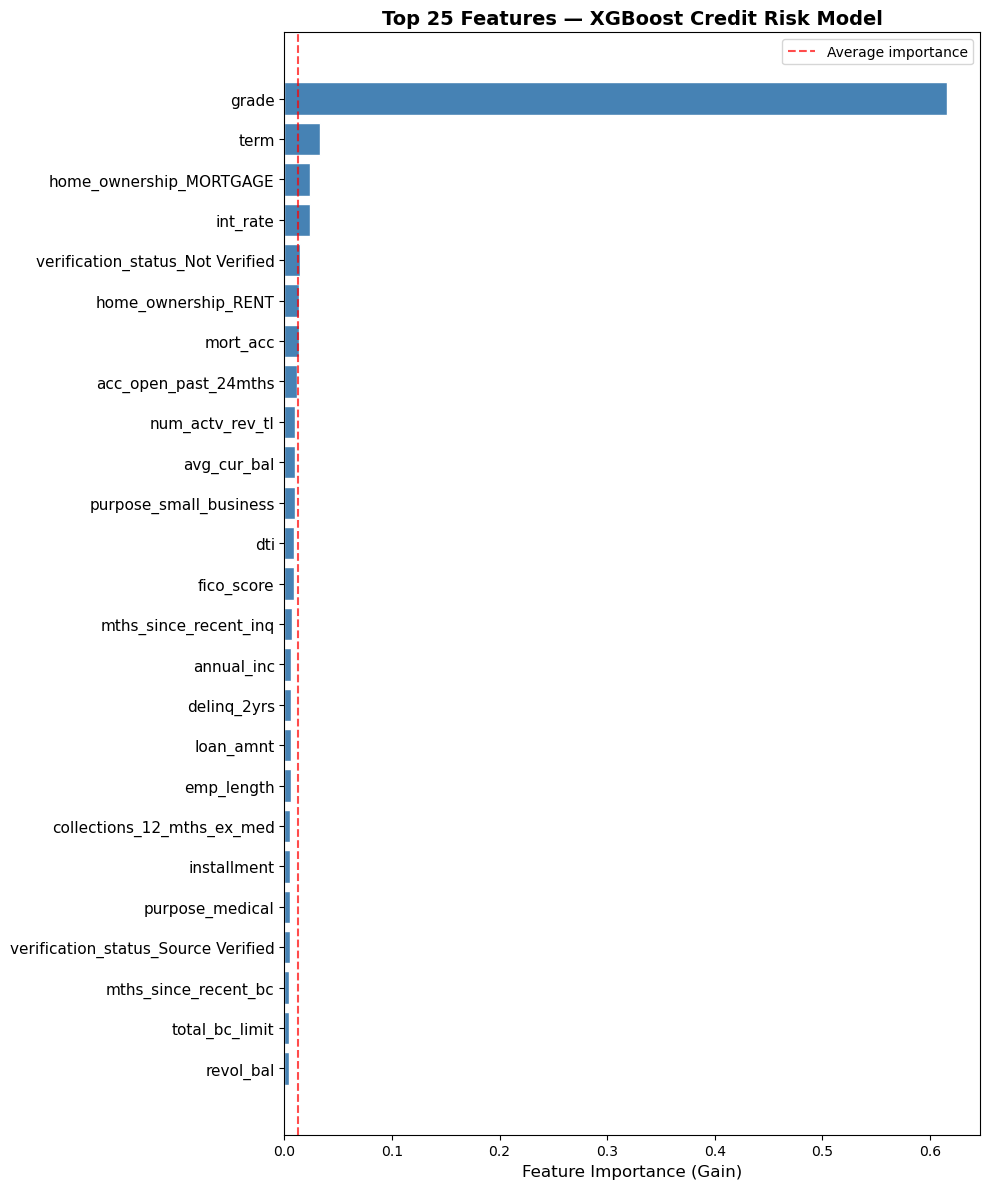

Plot saved to outputs folder


In [21]:
fig, ax = plt.subplots(figsize=(10, 12))

top_features = feature_importance.head(25)

bars = ax.barh(
    range(len(top_features)), 
    top_features['importance'].values,
    color='steelblue',
    edgecolor='white'
)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('Top 25 Features — XGBoost Credit Risk Model', fontsize=14, fontweight='bold')
ax.axvline(x=feature_importance['importance'].mean(), 
           color='red', linestyle='--', alpha=0.7, label='Average importance')
ax.legend()

plt.tight_layout()

# Save the plot
plot_path = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\outputs\feature_importance.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved to outputs folder")

In [23]:
# In our SAS project, DEBTINC (debt-to-income ratio) was the #1 predictor at 21%
# Let's check where 'dti' ranks in our much larger real-world dataset

dti_rank = feature_importance[
    feature_importance['feature'] == 'dti'
].index[0]

dti_importance = feature_importance[
    feature_importance['feature'] == 'dti'
]['importance'].values[0]

total_importance = feature_importance['importance'].sum()
dti_pct = dti_importance / total_importance * 100

print("=" * 55)
print("  SAS PROJECT VALIDATION TEST")
print("=" * 55)
print(f"\n  SAS project finding:")
print(f"  DEBTINC was #1 predictor, accounting for 21% of")
print(f"  predictive power on 5,960 HMEQ records")
print(f"\n  Lending Club finding (1,344,441 records):")
print(f"  'dti' ranks #{dti_rank + 1} out of 78 features")
print(f"  accounting for {dti_pct:.1f}% of predictive power")
print(f"\n  Top 5 features in current model:")
for idx, row in feature_importance.head(5).iterrows():
    pct = row['importance'] / total_importance * 100
    print(f"  {feature_importance.index.get_loc(idx)+1}. {row['feature']:<40} {pct:.1f}%")

  SAS PROJECT VALIDATION TEST

  SAS project finding:
  DEBTINC was #1 predictor, accounting for 21% of
  predictive power on 5,960 HMEQ records

  Lending Club finding (1,344,441 records):
  'dti' ranks #8 out of 78 features
  accounting for 0.9% of predictive power

  Top 5 features in current model:
  1. grade                                    61.6%
  2. term                                     3.3%
  3. home_ownership_MORTGAGE                  2.4%
  4. int_rate                                 2.3%
  5. verification_status_Not Verified         1.4%


In [25]:
# Remove grade and int_rate - both are assigned by Lending Club
# AFTER their own risk assessment, making them circular predictors
# A real scoring model must work from raw applicant data only

print("Removing circular predictors: grade, int_rate")
print(f"Features before: {X_train.shape[1]}")

# Remove from both train and test sets
cols_to_remove = ['grade', 'int_rate']
X_train_clean = X_train.drop(columns=cols_to_remove)
X_test_clean = X_test.drop(columns=cols_to_remove)

print(f"Features after:  {X_train_clean.shape[1]}")

# Also need to rescale for logistic regression
X_train_scaled_clean = scaler.fit_transform(X_train_clean)
X_test_scaled_clean = scaler.transform(X_test_clean)

print("\nRetraining both models without circular predictors...")

Removing circular predictors: grade, int_rate
Features before: 78
Features after:  76

Retraining both models without circular predictors...


In [27]:
print("Training Logistic Regression (no grade/int_rate)...")

lr_model_v2 = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model_v2.fit(X_train_scaled_clean, y_train)
lr_proba_v2 = lr_model_v2.predict_proba(X_test_scaled_clean)[:, 1]

lr_results_v2 = evaluate_model(
    "LOGISTIC REGRESSION v2 (no grade/int_rate)", 
    y_test, 
    lr_proba_v2
)

Training Logistic Regression (no grade/int_rate)...

  LOGISTIC REGRESSION v2 (no grade/int_rate)
  AUC Score:        0.7108
  Gini Coefficient: 0.4216  (industry benchmark: >0.40)
  KS Statistic:     0.3046  (industry benchmark: >0.30)
  Accuracy:         0.6586
  Precision:        0.3217
  Recall:           0.6408

  Confusion Matrix:
  True Negatives  (correctly identified good loans):  142,683
  False Positives (good loans flagged as bad):         72,529
  False Negatives (bad loans missed):                  19,283
  True Positives  (correctly identified defaults):     34,394


In [29]:
print("Training XGBoost (no grade/int_rate)...")

xgb_model_v2 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model_v2.fit(X_train_clean, y_train)
xgb_proba_v2 = xgb_model_v2.predict_proba(X_test_clean)[:, 1]

xgb_results_v2 = evaluate_model(
    "XGBOOST v2 (no grade/int_rate)", 
    y_test, 
    xgb_proba_v2
)

Training XGBoost (no grade/int_rate)...

  XGBOOST v2 (no grade/int_rate)
  AUC Score:        0.7254
  Gini Coefficient: 0.4507  (industry benchmark: >0.40)
  KS Statistic:     0.3254  (industry benchmark: >0.30)
  Accuracy:         0.6608
  Precision:        0.3277
  Recall:           0.6653

  Confusion Matrix:
  True Negatives  (correctly identified good loans):  141,961
  False Positives (good loans flagged as bad):         73,251
  False Negatives (bad loans missed):                  17,966
  True Positives  (correctly identified defaults):     35,711


In [31]:
print("\n" + "="*65)
print("  FULL MODEL COMPARISON")
print("="*65)
print(f"  {'Metric':<25} {'LR v1':>10} {'XGB v1':>10} {'LR v2':>10} {'XGB v2':>10}")
print("-"*65)

metrics = ['auc', 'gini', 'ks', 'precision', 'recall']
labels  = ['AUC', 'Gini', 'KS Statistic', 'Precision', 'Recall']

for metric, label in zip(metrics, labels):
    print(f"  {label:<25} "
          f"{lr_results[metric]:>10.4f} "
          f"{xgb_results[metric]:>10.4f} "
          f"{lr_results_v2[metric]:>10.4f} "
          f"{xgb_results_v2[metric]:>10.4f}")

print("="*65)
print("  v1 = with grade + int_rate (circular predictors)")
print("  v2 = without grade + int_rate (production-ready)")


  FULL MODEL COMPARISON
  Metric                         LR v1     XGB v1      LR v2     XGB v2
-----------------------------------------------------------------
  AUC                           0.7163     0.7300     0.7108     0.7254
  Gini                          0.4326     0.4599     0.4216     0.4507
  KS Statistic                  0.3148     0.3346     0.3046     0.3254
  Precision                     0.3255     0.3290     0.3217     0.3277
  Recall                        0.6505     0.6796     0.6408     0.6653
  v1 = with grade + int_rate (circular predictors)
  v2 = without grade + int_rate (production-ready)


Top 20 Most Important Features (grade/int_rate removed):
term                                          0.2719 █████████████████████████████████████████████████████████████████████████████████
fico_score                                    0.0728 █████████████████████
home_ownership_MORTGAGE                       0.0544 ████████████████
verification_status_Not Verified              0.0495 ██████████████
mort_acc                                      0.0312 █████████
purpose_credit_card                           0.0283 ████████
purpose_small_business                        0.0273 ████████
acc_open_past_24mths                          0.0271 ████████
home_ownership_RENT                           0.0253 ███████
dti                                           0.0230 ██████
mths_since_recent_inq                         0.0224 ██████
tot_hi_cred_lim                               0.0209 ██████
num_tl_op_past_12m                            0.0180 █████
annual_inc                                    

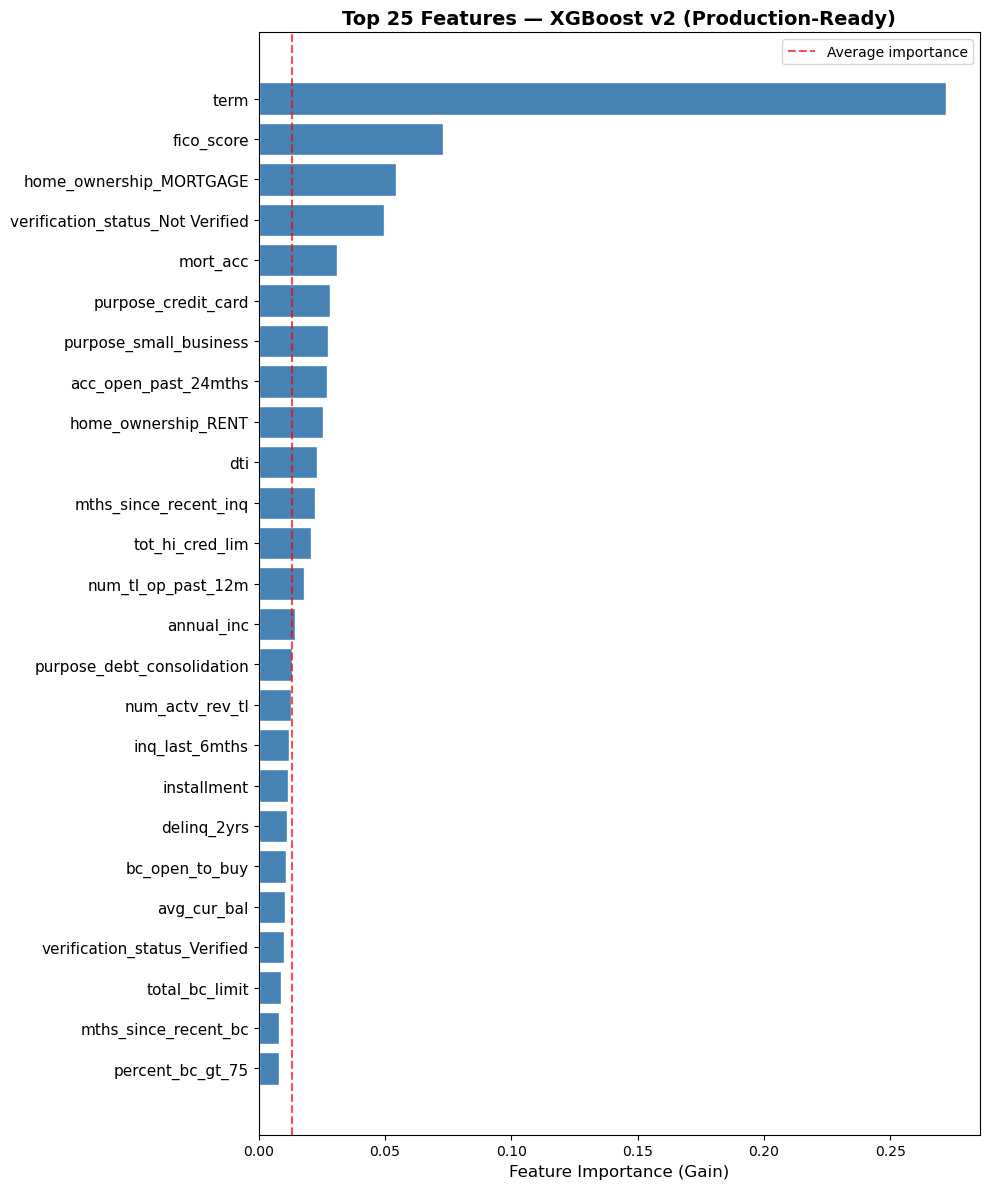

In [33]:
feature_importance_v2 = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importance': xgb_model_v2.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features (grade/int_rate removed):")
print("=" * 55)
for idx, row in feature_importance_v2.head(20).iterrows():
    bar = "█" * int(row['importance'] * 300)
    print(f"{row['feature']:<45} {row['importance']:.4f} {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
top_features_v2 = feature_importance_v2.head(25)

ax.barh(range(len(top_features_v2)), 
        top_features_v2['importance'].values,
        color='steelblue', edgecolor='white')

ax.set_yticks(range(len(top_features_v2)))
ax.set_yticklabels(top_features_v2['feature'].values, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('Top 25 Features — XGBoost v2 (Production-Ready)', 
             fontsize=14, fontweight='bold')
ax.axvline(x=feature_importance_v2['importance'].mean(),
           color='red', linestyle='--', alpha=0.7, label='Average importance')
ax.legend()
plt.tight_layout()

plot_path = r"C:\Users\DELL G3\Desktop\RMIT SEM - 4\Loan Club Project\outputs\feature_importance_v2.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

In [35]:
dti_row = feature_importance_v2[
    feature_importance_v2['feature'] == 'dti'
]
dti_rank = feature_importance_v2.index.get_loc(dti_row.index[0]) + 1
dti_pct = dti_row['importance'].values[0] / \
          feature_importance_v2['importance'].sum() * 100

print("=" * 55)
print("  SAS PROJECT VALIDATION TEST (v2 — fair comparison)")
print("=" * 55)
print(f"\n  SAS project finding:")
print(f"  DEBTINC was #1 predictor at 21% importance")
print(f"  Dataset: 5,960 HMEQ records, 13 features")
print(f"\n  Lending Club finding (production-ready model):")
print(f"  'dti' ranks #{dti_rank} out of 76 features")
dti_pct_str = f"{dti_pct:.1f}%"
print(f"  accounting for {dti_pct_str} of predictive power")
print(f"\n  Top 10 features in production model:")
total_imp = feature_importance_v2['importance'].sum()
for i, (idx, row) in enumerate(feature_importance_v2.head(10).iterrows()):
    pct = row['importance'] / total_imp * 100
    print(f"  {i+1:>2}. {row['feature']:<40} {pct:.1f}%")

  SAS PROJECT VALIDATION TEST (v2 — fair comparison)

  SAS project finding:
  DEBTINC was #1 predictor at 21% importance
  Dataset: 5,960 HMEQ records, 13 features

  Lending Club finding (production-ready model):
  'dti' ranks #10 out of 76 features
  accounting for 2.3% of predictive power

  Top 10 features in production model:
   1. term                                     27.2%
   2. fico_score                               7.3%
   3. home_ownership_MORTGAGE                  5.4%
   4. verification_status_Not Verified         5.0%
   5. mort_acc                                 3.1%
   6. purpose_credit_card                      2.8%
   7. purpose_small_business                   2.7%
   8. acc_open_past_24mths                     2.7%
   9. home_ownership_RENT                      2.5%
  10. dti                                      2.3%


In [37]:
# Does loan term actually correlate with default rate?
# If term is genuinely predictive, 60-month loans should default more

term_analysis = df.groupby('term')['target'].agg(['mean', 'count'])
term_analysis.columns = ['default_rate', 'loan_count']
term_analysis['default_rate_pct'] = term_analysis['default_rate'] * 100

print("Default Rate by Loan Term:")
print("=" * 45)
print(f"  {'Term':<15} {'Loans':>10} {'Default Rate':>15}")
print("-" * 45)
for term, row in term_analysis.iterrows():
    print(f"  {str(term)+' months':<15} "
          f"{int(row['loan_count']):>10,} "
          f"{row['default_rate_pct']:>14.2f}%")

print("\nConclusion:")
rate_36 = term_analysis.loc[36, 'default_rate_pct']
rate_60 = term_analysis.loc[60, 'default_rate_pct']
diff = rate_60 - rate_36
print(f"  60-month loans default {diff:.1f} percentage points")
print(f"  more than 36-month loans")
print(f"  This validates term as a genuine risk signal")

Default Rate by Loan Term:
  Term                 Loans    Default Rate
---------------------------------------------
  36 months        1,020,225          15.99%
  60 months          324,216          32.46%

Conclusion:
  60-month loans default 16.5 percentage points
  more than 36-month loans
  This validates term as a genuine risk signal


In [41]:
# Does FICO score correlate with default rate as expected?
# Higher FICO = better credit = lower default rate

# Create FICO score buckets
df['fico_bucket'] = pd.cut(df['fico_score'], 
                            bins=[620, 650, 670, 690, 710, 730, 760, 850],
                            labels=['620-650', '650-670', '670-690', 
                                   '690-710', '710-730', '730-760', '760+'])

fico_analysis = df.groupby('fico_bucket', observed=True)['target'].agg(
    ['mean', 'count']
)
fico_analysis.columns = ['default_rate', 'count']

print("Default Rate by FICO Score Range:")
print("=" * 50)
print(f"  {'FICO Range':<15} {'Loans':>10} {'Default Rate':>15}")
print("-" * 50)
for bucket, row in fico_analysis.iterrows():
    bar = "█" * int(row['default_rate'] * 100)
    print(f"  {str(bucket):<15} "
          f"{int(row['count']):>10,} "
          f"{row['default_rate']*100:>14.2f}%  {bar}")

# Clean up temp column
df = df.drop(columns=['fico_bucket'])

Default Rate by FICO Score Range:
  FICO Range           Loans    Default Rate
--------------------------------------------------
  620-650                  2           0.00%  
  650-670            237,582          26.28%  ██████████████████████████
  670-690            415,554          23.35%  ███████████████████████
  690-710            305,289          19.41%  ███████████████████
  710-730            186,532          15.34%  ███████████████
  730-760            122,553          11.94%  ███████████
  760+                76,929           8.32%  ████████
